In this file I will perform some analysis on the distribution of the plants present in the dataset.

Also I will perform analysis on the results of the Leave One Group Out Cross Validation results with 2 classes.

In [7]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np
%matplotlib inline

In [2]:
FILTERED_METADATA_PATH = './taxas/filtered_metadata'
INVASIVE_SPECIES = ['lythrum hyssopifolia', 'lythrum salicaria', 'lythrum virgatum']

In [3]:
species_dict = {}

for filename in os.listdir(FILTERED_METADATA_PATH):

    species_name = filename.strip('.csv').split(sep='_')[0] + " " + filename.strip('.csv').split(sep='_')[1]

    species_path = FILTERED_METADATA_PATH + '/' + filename
    species_df = pd.read_csv(species_path)
    
    if len(species_df!=0):
        species_dict[species_name] = len(species_df)

print(species_dict)

{'lythrum acutangulum': 24, 'lythrum alatum': 10491, 'lythrum album': 18, 'lythrum baeticum': 3, 'lythrum borysthenicum': 87, 'lythrum bryantii': 14, 'lythrum californicum': 2149, 'lythrum curtissii': 15, 'lythrum flagellare': 337, 'lythrum flexuosum': 54, 'lythrum gracile': 122, 'lythrum hyssopifolia': 9583, 'lythrum intermedium': 33, 'lythrum junceum': 3290, 'lythrum lineare': 445, 'lythrum maritimum': 226, 'lythrum netofa': 3, 'lythrum ovalifolium': 160, 'lythrum paradoxum': 8, 'lythrum portula': 2417, 'lythrum rotundifolium': 14, 'lythrum salicaria': 13105, 'lythrum silenoides': 2, 'lythrum thesioides': 1, 'lythrum thymifolia': 146, 'lythrum tribracteatum': 362, 'lythrum virgatum': 2145, 'lythrum volgense': 81, 'lythrum vulneraria': 22, 'lythrum wilsonii': 4}


In [4]:
tot_samples = sum(list(species_dict.values()))
print(tot_samples)
print(len(species_dict.keys()))

45361
30


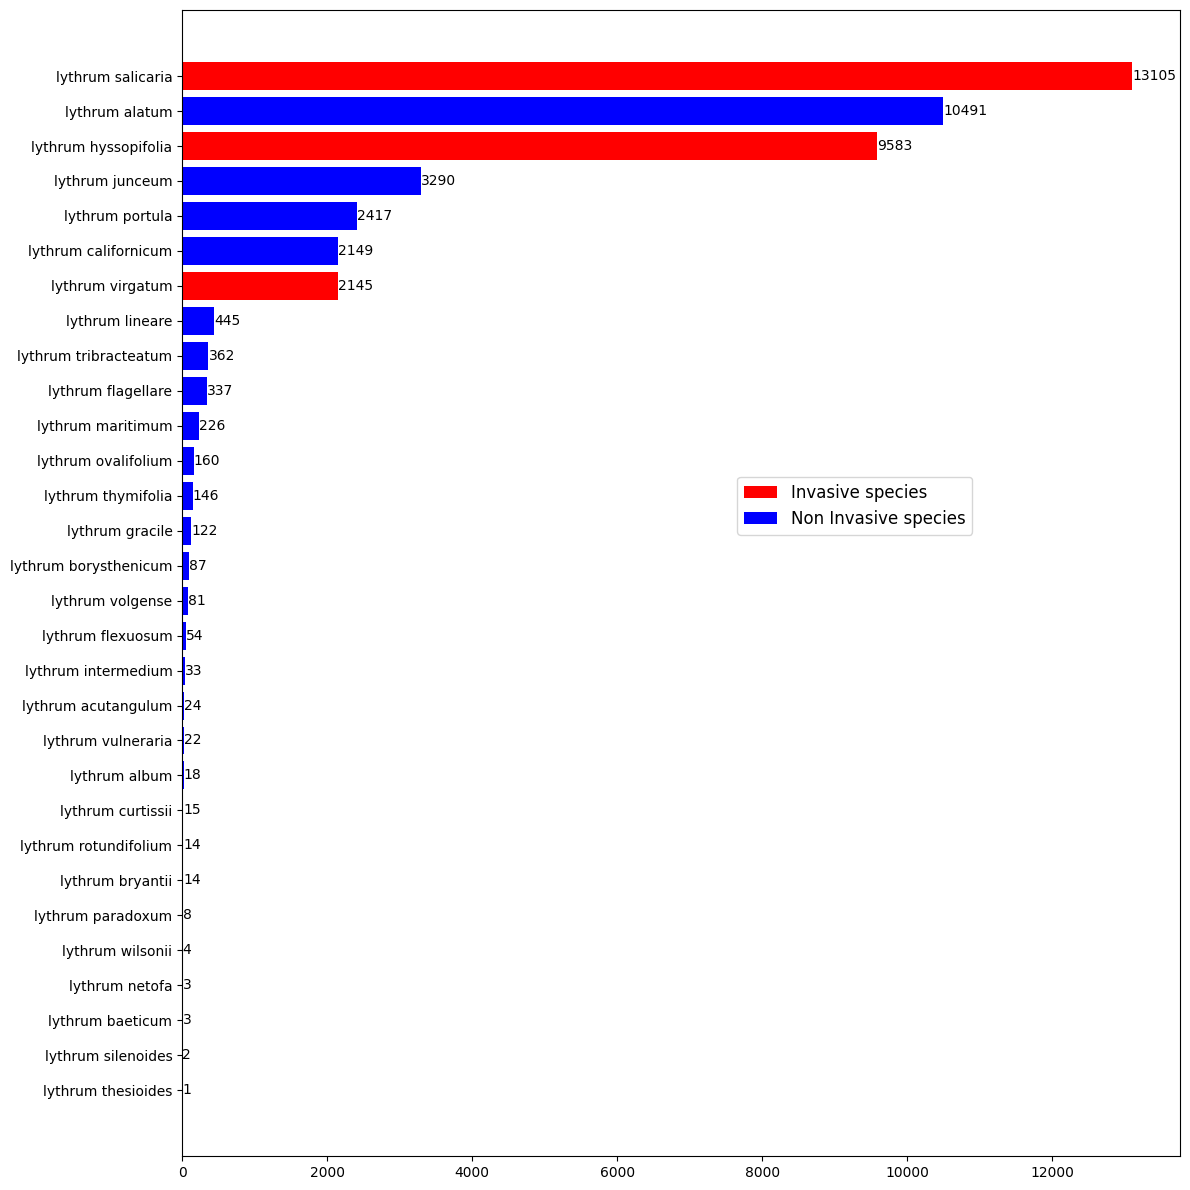

In [5]:
species_dict = dict(sorted(species_dict.items(), key=lambda item: item[1]))
# print(species_dict)

plt.style.use('default')

colors = [
    'r' if species in INVASIVE_SPECIES else 'blue' for species in species_dict.keys()
]

fig, ax = plt.subplots(figsize=(12,12))

bars = ax.barh(y=range(len(species_dict)), width=list(species_dict.values()), color=colors, align='center')

ax.set_yticks(range(len(species_dict)))
ax.set_yticklabels(list(species_dict.keys()))

ax.bar_label(bars)

legend_elements = [
    Patch(facecolor='red', label='Invasive species'),
    Patch(facecolor='blue', label='Non Invasive species')
]

ax.legend(handles=legend_elements, loc='best', bbox_to_anchor=(0.8,0.6), fontsize='large')

plt.tight_layout()
plt.show()

In [14]:
#Calculate quantiles

samples = list(species_dict.values())

q5 = np.quantile(samples, 0.05)
print("q5: ", q5)
q10 = np.quantile(samples, 0.10)
print("q10: ", q10)
q25 = np.quantile(samples, 0.25)
print("q25: ", q25)
q50 = np.quantile(samples, 0.5)
print("q50: ", q50)

#Q25 = 14.25, non contiamo nella validazione tutte le specie 

species_dict_sorted = dict(sorted(species_dict.items(), key=lambda item: -item[1]))

for i in range(30)[:18]:
    print(list(species_dict_sorted.keys())[i])

q5:  2.45
q10:  3.0
q25:  14.25
q50:  84.0
lythrum salicaria
lythrum alatum
lythrum hyssopifolia
lythrum junceum
lythrum portula
lythrum californicum
lythrum virgatum
lythrum lineare
lythrum tribracteatum
lythrum flagellare
lythrum maritimum
lythrum ovalifolium
lythrum thymifolia
lythrum gracile
lythrum borysthenicum
lythrum volgense
lythrum flexuosum
lythrum intermedium


### GROUP K FOLD ANALYSIS

In [ ]:
# 📊 Cross-validation results:
# Average Validation Loss: 1.0826
# Average Validation Accuracy: 0.7313
# All Fold Accuracies: [0.5137733689431515, 0.8123153178915261, 0.005739330063654388, 0.31732522796352586, 0.8249896565990897, 0.8599348534201955, 0.5888111888111888, 0.9752808988764045, 0.3342541436464088, 0.8902077151335311, 0.7743362831858407, 0.7875, 0.136986301369863, 0.8442622950819673, 0.7816091954022989, 0.7037037037037037, 0.9629629629629629, 0.0, 0.8333333333333334, 1.0, 1.0, 0.8666666666666667, 1.0, 1.0, 0.875, 0.25, 1.0, 1.0, 1.0, 1.0]

# 📊 Cross-validation results:
# Average Validation Loss (No small species): 1.3161
# Average Validation Accuracy (No small species): 0.6734
# All Fold Accuracies (No small species): [0.5137733689431515, 0.8123153178915261, 0.005739330063654388, 0.31732522796352586, 0.8249896565990897, 0.8599348534201955, 0.5888111888111888, 0.9752808988764045, 0.3342541436464088, 0.8902077151335311, 0.7743362831858407, 0.7875, 0.136986301369863, 0.8442622950819673, 0.7816091954022989, 0.7037037037037037, 0.9629629629629629, 0.0, 0.8333333333333334, 1.0, 1.0, 0.8666666666666667]

In [ ]:
val_accuracy = [0.5137733689431515, 0.8123153178915261, 0.005739330063654388, 0.31732522796352586, 0.8249896565990897, 0.8599348534201955, 0.5888111888111888, 0.9752808988764045, 0.3342541436464088, 0.8902077151335311, 0.7743362831858407, 0.7875, 0.136986301369863, 0.8442622950819673, 0.7816091954022989, 0.7037037037037037, 0.9629629629629629, 0.0, 0.8333333333333334, 1.0, 1.0, 0.8666666666666667, 1.0, 1.0, 0.875, 0.25, 1.0, 1.0, 1.0, 1.0]

reduced_val_accuracy = [0.5137733689431515, 0.8123153178915261, 0.005739330063654388, 0.31732522796352586, 0.8249896565990897, 0.8599348534201955, 0.5888111888111888, 0.9752808988764045, 0.3342541436464088, 0.8902077151335311, 0.7743362831858407, 0.7875, 0.136986301369863, 0.8442622950819673, 0.7816091954022989, 0.7037037037037037, 0.9629629629629629, 0.0, 0.8333333333333334, 1.0, 1.0, 0.8666666666666667]

species_accuracy = dict(zip(list(species_dict_sorted.keys()), val_accuracy))

species_accuracy


{'lythrum salicaria': 0.5137733689431515,
 'lythrum alatum': 0.8123153178915261,
 'lythrum hyssopifolia': 0.005739330063654388,
 'lythrum junceum': 0.31732522796352586,
 'lythrum portula': 0.8249896565990897,
 'lythrum californicum': 0.8599348534201955,
 'lythrum virgatum': 0.5888111888111888,
 'lythrum lineare': 0.9752808988764045,
 'lythrum tribracteatum': 0.3342541436464088,
 'lythrum flagellare': 0.8902077151335311,
 'lythrum maritimum': 0.7743362831858407,
 'lythrum ovalifolium': 0.7875,
 'lythrum thymifolia': 0.136986301369863,
 'lythrum gracile': 0.8442622950819673,
 'lythrum borysthenicum': 0.7816091954022989,
 'lythrum volgense': 0.7037037037037037,
 'lythrum flexuosum': 0.9629629629629629,
 'lythrum intermedium': 0.0,
 'lythrum acutangulum': 0.8333333333333334,
 'lythrum vulneraria': 1.0,
 'lythrum album': 1.0,
 'lythrum curtissii': 0.8666666666666667,
 'lythrum bryantii': 1.0,
 'lythrum rotundifolium': 1.0,
 'lythrum paradoxum': 0.875,
 'lythrum wilsonii': 0.25,
 'lythrum ba

In [17]:
print("Just for species with a number of samples >= 15")
val_accuracy_mean = np.mean(reduced_val_accuracy)
val_accuracy_std = np.std(reduced_val_accuracy)

print(f"Mean accuracy +- std : {val_accuracy_mean:.3f} +- {val_accuracy_std:.3f}")

Just for species with a number of samples >= 15
Mean accuracy +- std : 0.673 +- 0.309


Lythrum Hyssopifolia (invasiva) viene quasi sempre classificata come Non Invasiva

### What happens if we remove Lythrum Hyssopifolia from training?

In [ ]:
#copied from "testing_strategeis_training.ipynb"
no_hyssopifolia = {
    'lythrum_salicaria' : 0.6038916,
    'lythrum_alatum' : 0.836240,
    'lythrum_junceum' : 0.95623,
    'lythrum_portula' : 0.98220,
    'lythrum_californicum' : 0.973476,
    'lythrum_virgatum' : 0.599533,
    'lythrum_lineare' : 0.970786,
    'lythrum_tribracteatum' : 0.9751381,
    'lythrum_flagellare' : 1.0,
    'lythrum_maritimum' : 0.964601,
    'lythrum_ovalifolium' : 0.9875,
    'lythrum_thymifolia' : 1.0,
    'lythrum_gracile' : 0.9754098,
    'lythrum_borysthenicum' : 0.988505,
    'lythrum_volgense' : 0.925925,
    'lythrum_flexuosum' : 0.981481,
    'lythrum_intermedium' : 0.0,
    'lythrum_acutangulum' : 1.0,
    'lythrum_vulneraria' : 1.0,
    'lythrum_album' : 1.0,
    'lythrum_curtissii' : 0.8666666666666667, #This is the last one with >=15 samples
    'lythrum_rotundifolium' : 1.0,
    'lythrum_bryantii' : 1.0,
    'lythrum_paradoxum' + ' + ' + 'lythrum_silenoides' + ' + ' + 'lythrum_thesioides': 1.0, 
    'lythrum_baeticum'+ ' + ' +'lythrum_netofa'+ ' + ' + 'lythrum_wilsonii' : 1.0
}

print(list(no_hyssopifolia.keys())[:21])

print("Results for species with a number of samples >= 15 (without Hyssopifolia)")
no_hy_val_accuracy_mean = np.mean(list(no_hyssopifolia.values())[:21])
no_hy_val_accuracy_std = np.std(list(no_hyssopifolia.values())[:21])

print(f"Mean accuracy +- std : {no_hy_val_accuracy_mean:.3f} +- {no_hy_val_accuracy_std:.3f}")



['lythrum_salicaria', 'lythrum_alatum', 'lythrum_junceum', 'lythrum_portula', 'lythrum_californicum', 'lythrum_virgatum', 'lythrum_lineare', 'lythrum_tribracteatum', 'lythrum_flagellare', 'lythrum_maritimum', 'lythrum_ovalifolium', 'lythrum_thymifolia', 'lythrum_gracile', 'lythrum_borysthenicum', 'lythrum_volgense', 'lythrum_flexuosum', 'lythrum_intermedium', 'lythrum_acutangulum', 'lythrum_vulneraria', 'lythrum_album', 'lythrum_curtissii']
Results for species with a number of samples >= 15 (without Hyssopifolia)
Mean accuracy +- std : 0.885 +- 0.229


Now we test what happens if we augment the samples of Lythrum Virgatum x2, to balance more the training set after the removal of Hyssopifolia as an invasive species

In [17]:
no_hyssopifolia_augmenting_virgatum = {
    'lythrum_salicaria' : 0.7153,
    'lythrum_alatum' : 0.8489,
    'lythrum_junceum' : 0.9641,
    'lythrum_portula' : 0.9892,
    'lythrum_californicum' : 0.9102,
    'lythrum_lineare' : 0.9640,
    'lythrum_tribracteatum' : 0.9724,
    'lythrum_flagellare' : 1.0,
    'lythrum_maritimum' : 0.9735,
    'lythrum_ovalifolium' : 0.9875,
    'lythrum_thymifolia' : 1.0,
    'lythrum_gracile' : 0.9836,
    'lythrum_borysthenicum' : 0.9885,
    'lythrum_volgense' : 0.9506,
    'lythrum_flexuosum' : 0.9630,
    'lythrum_intermedium' : 0.0,
    'lythrum_acutangulum' : 1.0,
    'lythrum_vulneraria' : 1.0,
    'lythrum_album' : 1.0,
    'lythrum_curtissii' : 0.8667, #This is the last one with >=15 samples
    'lythrum_rotundifolium' : 1.0,
    'lythrum_bryantii' : 1.0,
    'lythrum_paradoxum' + ' + ' + 'lythrum_silenoides' + ' + ' + 'lythrum_thesioides': 0.9091, 
    'lythrum_baeticum'+ ' + ' +'lythrum_netofa'+ ' + ' + 'lythrum_wilsonii' : 1
}

print("Results for species with a number of samples >= 15 (without Hyssopifolia and augmenting virgatum x2)")
no_hy_aug_vir_val_accuracy_mean = np.mean(list(no_hyssopifolia_augmenting_virgatum.values())[:21])
no_hy_aug_vir_val_accuracy_std = np.std(list(no_hyssopifolia_augmenting_virgatum.values())[:21])

print(f"Mean accuracy +- std : {no_hy_aug_vir_val_accuracy_mean:.3f} +- {no_hy_aug_vir_val_accuracy_std:.3f}")

Results for species with a number of samples >= 15 (without Hyssopifolia and augmenting virgatum x2)
Mean accuracy +- std : 0.908 +- 0.214


In [24]:
no_hyssopifolia_no_virgatum = np.array([v for k,v in no_hyssopifolia.items() if k !='lythrum_virgatum'])

print(no_hyssopifolia_no_virgatum)

print("Results for species with a number of samples >= 15 (without Hyssopifolia and without virgatum to compare it with the results above which do not include virgatum (used for augmentation))")
no_hyssopifolia_no_virgatum_mean = np.mean(no_hyssopifolia_no_virgatum[:20])
no_hyssopifolia_no_virgatum_std = np.std(no_hyssopifolia_no_virgatum[:20])

print(f"Mean accuracy +- std : {no_hyssopifolia_no_virgatum_mean:.3f} +- {no_hyssopifolia_no_virgatum_std:.3f}")

[0.6038916  0.83624    0.95623    0.9822     0.973476   0.970786
 0.9751381  1.         0.964601   0.9875     1.         0.9754098
 0.988505   0.925925   0.981481   0.         1.         1.
 1.         0.86666667 1.         1.         1.         1.        ]
Results for species with a number of samples >= 15 (without Hyssopifolia and without virgatum to compare it with the results above which do not include virgatum (used for augmentation))
Mean accuracy +- std : 0.899 +- 0.225
